# CA - Machine Learning
Energy Efficiency Classification

Dataset: DataBase.csv

In [56]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# Importing the dataset
dataset = pd.read_csv('DataBase.csv')

dataset.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [58]:
# Checking the shape of the dataset
dataset.shape

(768, 10)

In [59]:
# Statistical sumary
dataset.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [60]:
# Checking missing values
dataset.isnull().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

In [61]:
# Checking column names
dataset.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')

In [62]:
# Renaming the columns
dataset.columns = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                   'Overall_Height', 'Orientation', 'Glazing_Area',
                   'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']

In [63]:
dataset.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [64]:
# Creating the target variable
median_value = dataset['Heating_Load'].median()

dataset['Efficient'] = (dataset['Heating_Load'] < median_value).astype(int)

In [65]:
dataset.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load,Efficient
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33,1
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33,1
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33,1
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33,1
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28,0


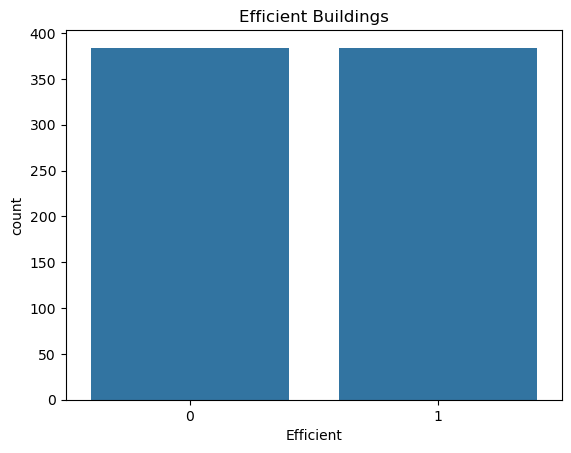

In [66]:
# Visualising the target variable
sns.countplot(x='Efficient', data=dataset)
plt.title('Efficient Buildings')
plt.show()

In [67]:
# Spliting the dataset, independent and dependent variables
X = dataset.drop(['Heating_Load', 'Cooling_Load', 'Efficient'], axis=1)

y = dataset['Efficient']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [68]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import metrics

In [69]:
# Three differents test splits
splits = [0.05, 0.15, 0.25]

gnb_results = []
svm_results = []

In [70]:
# Aplying gaussian naive bayes for differents splits
for s in splits:
    
    # Splitting the dataset into the training set and Test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=s, random_state=1)
    
    # Feature scaling
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)
    
    # Fitting gaussian naive bayes to the training set
    nvclassifier = GaussianNB()
    
    # Applying cross validation
    cv_scores = cross_val_score(nvclassifier, X_train_scaled, y_train, cv=5)
    
    # Training the model
    nvclassifier.fit(X_train_scaled, y_train)
    
    # Predict the test set result
    y_pred = nvclassifier.predict(X_test_scaled)
    
    # Accuracy score
    accuracy = metrics.accuracy_score(y_test, y_pred)
    
    print("Gaussian NB - Test size:", int(s*100), "%")
    print("Cross Validation Accuracy:", round(cv_scores.mean(), 4))
    print("Test Accuracy:", round(accuracy, 4))
    
    gnb_results.append([s, cv_scores.mean(), cv_scores.std(), accuracy])

Gaussian NB - Test size: 5 %
Cross Validation Accuracy: 0.9753
Test Accuracy: 1.0
Gaussian NB - Test size: 15 %
Cross Validation Accuracy: 0.9739
Test Accuracy: 0.9914
Gaussian NB - Test size: 25 %
Cross Validation Accuracy: 0.9757
Test Accuracy: 0.9792


In [71]:
# Apply support vector machine for differents splits
for s in splits:
    
    # Split the dataset into the training set and test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=s, random_state=1)
    
    # Feature scaling
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)
    
    # Fitting SVM to the training set
    svc_model = SVC(kernel='rbf', random_state=1)
    
    # Applying cross validation
    cv_scores = cross_val_score(svc_model, X_train_scaled, y_train, cv=5)
    
    # Training the model
    svc_model.fit(X_train_scaled, y_train)
    
    # Predict the test set results
    y_pred = svc_model.predict(X_test_scaled)
    
    # Accuracy score
    accuracy = metrics.accuracy_score(y_test, y_pred)
    
    print("SVM - Test size:", int(s*100), "%")
    print("Cross Validation Accuracy:", round(cv_scores.mean(), 4))
    print("Test Accuracy:", round(accuracy, 4))
    
    svm_results.append([s, cv_scores.mean(), cv_scores.std(), accuracy])

SVM - Test size: 5 %
Cross Validation Accuracy: 0.9753
Test Accuracy: 1.0
SVM - Test size: 15 %
Cross Validation Accuracy: 0.9739
Test Accuracy: 0.9914
SVM - Test size: 25 %
Cross Validation Accuracy: 0.9757
Test Accuracy: 0.9792


In [72]:
# Creating the results table
gnb_df = pd.DataFrame(gnb_results, columns=['Test Size', 'CV Mean', 'CV Std', 'Test Accuracy'])
svm_df = pd.DataFrame(svm_results, columns=['Test Size', 'CV Mean', 'CV Std', 'Test Accuracy'])

gnb_df['Model'] = 'Gaussian NB'
svm_df['Model'] = 'SVM'

summary = pd.concat([gnb_df, svm_df])

summary['Test Size'] = (summary['Test Size'] * 100).astype(int).astype(str) + '%'

summary

,Test Size,CV Mean,CV Std,Test Accuracy,Model
0,5%,0.975305,0.005499,1.000000,Gaussian NB
1,15%,0.973928,0.014184,0.991379,Gaussian NB
2,25%,0.975712,0.010080,0.979167,Gaussian NB
0,5%,0.975305,0.005499,1.000000,SVM
1,15%,0.973928,0.014184,0.991379,SVM
2,25%,0.975712,0.010080,0.979167,SVM


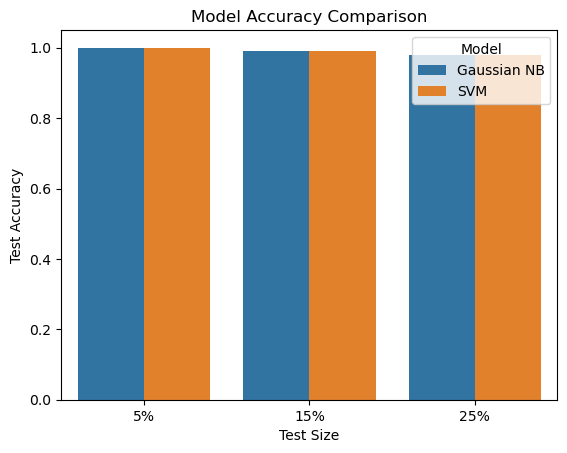

In [73]:
# Visual model result
sns.barplot(x='Test Size', y='Test Accuracy', hue='Model', data=summary)
plt.title('Model Accuracy Comparison')
plt.show()

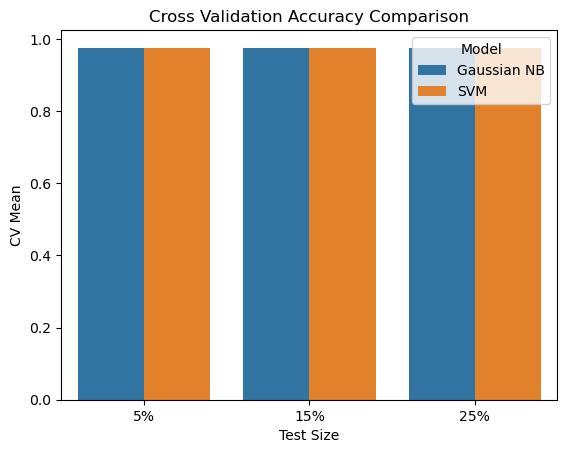

In [74]:
# Visual cross validation result
sns.barplot(x='Test Size', y='CV Mean', hue='Model', data=summary)
plt.title('Cross Validation Accuracy Comparison')
plt.show()

In [75]:
# Split dataset into the training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [76]:
# Feature scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [77]:
# Fitting gaussian naive bayes to the training set
nvclassifier = GaussianNB()
nvclassifier.fit(X_train_scaled, y_train)


GaussianNB()

In [78]:

# Predicting the test set results
y_pred_gnb = nvclassifier.predict(X_test_scaled)

In [79]:
# Making the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_gnb)

print(cm)

[[102   1]
 [  3  86]]


In [80]:
# Accuracy score
print(metrics.accuracy_score(y_test, y_pred_gnb))

# Classification report
print(metrics.classification_report(y_test, y_pred_gnb))

0.9791666666666666
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       103
           1       0.99      0.97      0.98        89

    accuracy                           0.98       192
   macro avg       0.98      0.98      0.98       192
weighted avg       0.98      0.98      0.98       192



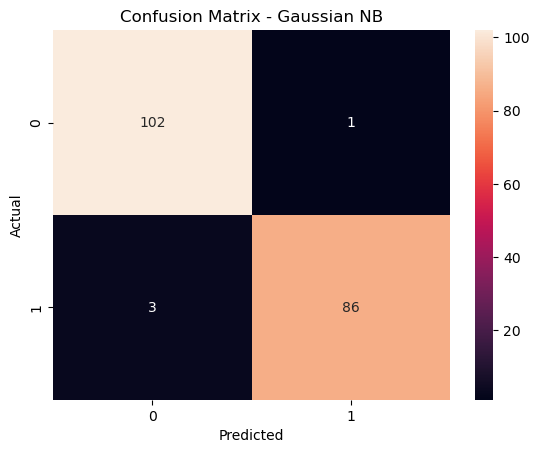

In [82]:
# Visualising confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Gaussian NB')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [83]:
# Fitting SVM to the training set
svc_model = SVC(kernel='rbf', random_state=1)
svc_model.fit(X_train_scaled, y_train)

# Predicting the test set results
y_pred_svm = svc_model.predict(X_test_scaled)

In [84]:
# Make the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_svm)

print(cm)

[[102   1]
 [  3  86]]


In [85]:
# Accuracy score
print(metrics.accuracy_score(y_test, y_pred_svm))

# Classification report
print(metrics.classification_report(y_test, y_pred_svm))

0.9791666666666666
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       103
           1       0.99      0.97      0.98        89

    accuracy                           0.98       192
   macro avg       0.98      0.98      0.98       192
weighted avg       0.98      0.98      0.98       192



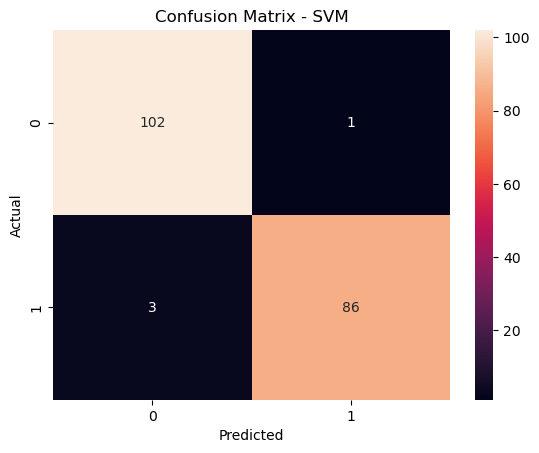

In [86]:
# Visual the confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler

In [89]:
# Feature scaling using MinMaxScaler
n_scaler = MinMaxScaler()

X_train_minmax = n_scaler.fit_transform(X_train.astype(float))
X_test_minmax = n_scaler.transform(X_test.astype(float))

In [90]:
# Setting parameters
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

In [91]:
# Fitting GridSearchCV to the training set
grid = GridSearchCV(SVC(), param_grid)

grid.fit(X_train_minmax, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf']})